In [2]:
# ==========================================
# CELL 1: Install Dependencies
# ==========================================
# We need the transformers library, datasets for handling JSON, and rouge for metrics.
!pip install -q transformers datasets evaluate rouge_score sentencepiece accelerate

In [4]:
# ==========================================
# CELL 2: Imports & Configuration
# ==========================================
import os
import torch
import nltk
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)
import evaluate
from huggingface_hub import login

# Download NLTK data for metric splitting
nltk.download("punkt", quiet=True)

# --- CONFIGURATION ---
# Replace this with the actual path to your uploaded dataset on Kaggle
dataset_path = "/kaggle/input/urdu-news-headlinearticle/combined_renumbered.ndjson" 
model_checkpoint = "google/byt5-small"
output_dir = "byt5-urdu-headline-generator"

# --- LOGIN TO HUGGING FACE (Recommended for Checkpointing) ---
# This ensures that if Kaggle disconnects, your model is saved online.
# Replace 'YOUR_HF_TOKEN_HERE' with your actual token, or paste it when prompted.
from kaggle_secrets import UserSecretsClient
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("Hugging ") # Save your token in Kaggle Add-ons -> Secrets
    login(token=hf_token)
except:
    print("HF Token not found in secrets. Please login manually below:")
    login() # Will prompt for token input

In [5]:
# ==========================================
# CELL 3 (OPTIMIZED): Load and Prepare Data
# ==========================================

# 1. Load the dataset
dataset = load_dataset("json", data_files=dataset_path, split="train")
dataset = dataset.train_test_split(test_size=0.1, seed=42)
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# --- OPTIMIZATION CHANGE ---
# Reduced from 2048 to 1024. 
# 1024 bytes is approx 500-600 Urdu characters (enough for the first 2 paragraphs).
max_input_length = 1024 
max_target_length = 128

def preprocess_function(examples):
    inputs = [doc for doc in examples["text"]]
    model_inputs = tokenizer(inputs, max_length=max_input_length, truncation=True)

    labels = tokenizer(text_target=examples["headline"], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = dataset.map(preprocess_function, batched=True, remove_columns=dataset["train"].column_names)
print("Data re-processed with length 1024.")

Generating train split: 0 examples [00:00, ? examples/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/22515 [00:00<?, ? examples/s]

Map:   0%|          | 0/2502 [00:00<?, ? examples/s]

Data re-processed with length 1024.


In [8]:
# ==========================================
# CELL 4: Metrics Setup (ROUGE)
# ==========================================
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Replace -100 in the labels as we can't decode them
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Rouge expects newline after each sentence for better scoring
    decoded_preds = ["\n".join(nltk.sent_tokenize(pred.strip())) for pred in decoded_preds]
    decoded_labels = ["\n".join(nltk.sent_tokenize(label.strip())) for label in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds, 
        references=decoded_labels, 
        use_stemmer=True
    )
    
    return {k: round(v * 100, 4) for k, v in result.items()}

In [ ]:
# ==========================================
# CELL 5 (STABLE & FAST): FP32 Fix
# ==========================================
import torch
import gc
from huggingface_hub import HfApi

# 1. Force Clean Memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# 2. Get Username
try:
    api = HfApi()
    username = api.whoami()['name']
except:
    username = "Lifon21" 
hub_id = f"{username}/{output_dir}"

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

args = Seq2SeqTrainingArguments(
    output_dir=output_dir,
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    learning_rate=4e-4,
    
    # --- STABILITY & SPEED CONFIG ---
    fp16=False,                     # <--- CHANGED: Must be False to prevent NaN/0.0 loss
    per_device_train_batch_size=2,  # <--- CHANGED: Lowered to 2 to fit in memory with fp32
    gradient_accumulation_steps=2,  # <--- CHANGED: Accumulate to simulate batch size 4
    num_train_epochs=2,             # Keep at 2 for speed
    # --------------------------------
    
    per_device_eval_batch_size=2,   # Lower eval batch size as well
    weight_decay=0.01,
    save_total_limit=2,
    predict_with_generate=True,
    push_to_hub=True,
    hub_model_id=hub_id,
    logging_dir=f"{output_dir}/logs",
    logging_steps=100,
    report_to="tensorboard",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    processing_class=tokenizer, 
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting STABLE training (FP32, Batch 2, Accumulation 2)...")
trainer.train()

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Starting STABLE training (FP32, Batch 2, Accumulation 2)...


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1000,0.391600,0.382331,1.072500,0.000000,1.079100,1.079100
2000,0.385100,0.341078,0.732700,0.000000,0.719400,0.732700
3000,0.352200,0.329022,0.999200,0.000000,0.999200,1.012500
4000,0.339100,0.319191,0.985900,0.000000,0.972600,0.972600
5000,0.338200,0.313287,0.905900,0.000000,0.905900,0.905900
6000,0.290900,0.299272,1.159100,0.000000,1.147100,1.159100
7000,0.282600,0.292791,1.291000,0.000000,1.284300,1.279000
8000,0.298700,0.285830,1.790600,0.000000,1.790600,1.785200
9000,0.272200,0.283206,1.534800,0.040000,1.545400,1.532100
10000,0.266800,0.273692,1.534800,0.040000,1.524100,1.548100


In [9]:
# ==========================================
# CELL 6 (ALTERNATIVE): Load Model from Hub
# ==========================================
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq
from huggingface_hub import HfApi

# 1. Get Username to find your model
try:
    api = HfApi()
    username = api.whoami()['name']
except:
    username = "Lifon21" # Replace manually if detection fails

# 2. Define where your model is located
# This matches the folder name we used earlier
model_id = f"{username}/byt5-urdu-headline-generator"
print(f"Loading trained model from: {model_id} ...")

# 3. Load Model and Tokenizer
try:
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    print("✅ Model loaded successfully!")
except Exception as e:
    print(f"❌ Could not load from Hub. Error: {e}")
    print("If the model isn't on the Hub, check if local files exist in '/kaggle/working/byt5-urdu-headline-generator'")

# 4. Re-create the Trainer (Just for Evaluation)
# We need this object to run the 'compute_metrics' function easily
args = Seq2SeqTrainingArguments(
    output_dir="temp_eval",
    per_device_eval_batch_size=4,
    predict_with_generate=True,
    fp16=False, # Keep False for stability
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics, # This uses the ROUGE function defined in Cell 4
)

print("Trainer ready. You can now run Cell 7 (Evaluation).")

Loading trained model from: Lifon21/byt5-urdu-headline-generator ...
✅ Model loaded successfully!


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Trainer ready. You can now run Cell 7 (Evaluation).


In [12]:
# ==========================================
# CELL 6: Save and Test
# ==========================================

# Save final model locally and to Hub
trainer.save_model()
tokenizer.save_pretrained(output_dir)
trainer.create_model_card()
trainer.push_to_hub()

# TEST GENERATION
print("\n--- Testing Model on a Sample ---")
sample_text = dataset["test"][0]["text"]
actual_headline = dataset["test"][0]["headline"]

inputs = tokenizer(sample_text, return_tensors="pt", max_length=2048, truncation=True).input_ids.to("cuda")
outputs = model.generate(inputs, max_new_tokens=100, do_sample=False)
generated_headline = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f"Article Segment: {sample_text[:200]}...")
print(f"Actual Headline: {actual_headline}")
print(f"Generated Headline: {generated_headline}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.



--- Testing Model on a Sample ---
Article Segment: سابق وزیر داخلہ اور سربراہ عوامی مسلم لیگ شیخ رشید نے کہا ہے کہ اسٹیبلشمنٹ کل کے الیکشن سے دور رہے، قوم کسی قسم کی غنڈہ گردی برداشت نہیں کرے گی۔ ٹوئٹر پر جاری ویڈیو پیغام میں انہوں نے کہا کہ اٹک کی عد...
Actual Headline: اسٹیبلشمنٹ الیکشن سے دور رہے، قوم غنڈہ گردی برداشت نہیں کرے گی، شیخ رشید
Generated Headline: اسٹیبلشمنٹ کل کے الیکشن سے دور رہے، قوم کسی قسم کی غنڈہ 


In [7]:
# ==========================================
# CELL 7 (ROBUST EVALUATION): Handles Data Errors
# ==========================================
import torch
from tqdm.auto import tqdm
import numpy as np
import nltk
from datasets import load_dataset
import pandas as pd

# 1. RELOAD DATASET
# Replace with your actual path!
dataset_path = "/kaggle/input/urdu-news-headlinearticle/combined_renumbered.ndjson" 
try:
    raw_dataset = load_dataset("json", data_files=dataset_path, split="train")
    # Use same split seed as training to ensure we test on the right data
    raw_dataset = raw_dataset.train_test_split(test_size=0.1, seed=42)
    test_dataset = raw_dataset["test"]
    print(f"Evaluating on {len(test_dataset)} samples...")
except Exception as e:
    print(f"Error loading dataset: {e}")
    # Stop execution if dataset load fails
    raise e

# 2. Setup Inference
predictions = []
references = []

model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

batch_size = 8

# 3. Inference Loop with SANITIZATION
for i in tqdm(range(0, len(test_dataset), batch_size), desc="Generating Headlines"):
    # Get batch
    batch_indices = range(i, min(i + batch_size, len(test_dataset)))
    batch = test_dataset.select(batch_indices)
    
    # --- FIX IS HERE: CLEAN THE DATA ---
    raw_texts = batch["text"]
    # Force everything to string; convert None to empty string
    clean_texts = [str(t) if t is not None else "" for t in raw_texts]
    # -----------------------------------
    
    # Tokenize
    inputs = tokenizer(
        clean_texts, 
        max_length=1024, 
        truncation=True, 
        padding="max_length", 
        return_tensors="pt"
    ).input_ids.to(device)
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(
            inputs, 
            max_new_tokens=64, 
            num_beams=2,
            early_stopping=True
        )
    
    # Decode
    batch_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    batch_refs = batch["headline"]
    
    predictions.extend(batch_preds)
    references.extend(batch_refs)

# 4. Compute ROUGE
print("\nComputing ROUGE scores...")
import evaluate
rouge = evaluate.load("rouge")

def postprocess_text(preds, refs):
    # Handle potential None in references too
    preds = [str(pred).strip() if pred is not None else "" for pred in preds]
    refs = [str(ref).strip() if ref is not None else "" for ref in refs]
    
    preds = ["\n".join(nltk.sent_tokenize(pred)) for pred in preds]
    refs = ["\n".join(nltk.sent_tokenize(ref)) for ref in refs]
    return preds, refs

decoded_preds, decoded_labels = postprocess_text(predictions, references)

result = rouge.compute(
    predictions=decoded_preds, 
    references=decoded_labels, 
    use_stemmer=True
)

# 5. Print Results
print("\n" + "="*30)
print("   FINAL ROUGE SCORES")
print("="*30)
print(f"ROUGE-1: {result['rouge1']*100:.2f}%")
print(f"ROUGE-2: {result['rouge2']*100:.2f}%")
print(f"ROUGE-L: {result['rougeL']*100:.2f}%")
print("="*30)

# 6. Show Visual Samples
df = pd.DataFrame({
    'Actual Headline': references[:5],
    'Generated Headline': predictions[:5]
})
pd.set_option('display.max_colwidth', None)
display(df)

Evaluating on 2502 samples...


NameError: name 'model' is not defined

In [20]:
# ==========================================
# CELL 8: Calculate BERTScore
# ==========================================
# 1. Install bert_score library
!pip install -q bert_score

import evaluate
import numpy as np
import torch

print("Loading BERTScore metric...")
bertscore = evaluate.load("bertscore")

# 2. Compute Scores
# lang="ur" automatically loads 'bert-base-multilingual-cased'
# We use the 'predictions' and 'references' variables from the previous cell
print("Computing BERTScore (this involves downloading a ~700MB model)...")

results = bertscore.compute(
    predictions=predictions, 
    references=references, 
    lang="ur", 
    device="cuda" if torch.cuda.is_available() else "cpu",
    batch_size=16 # Faster batch processing
)

# 3. Print Averages
print("\n" + "="*30)
print("   FINAL BERTSCORE (URDU)")
print("="*30)
print(f"Precision: {np.mean(results['precision']):.4f}  (How accurate the generated words are)")
print(f"Recall:    {np.mean(results['recall']):.4f}  (How much of the reference meaning was captured)")
print(f"F1:        {np.mean(results['f1']):.4f}  (Overall quality)")
print("="*30)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.0 MB/s eta 0:00:00
Loading BERTScore metric...


Computing BERTScore (this involves downloading a ~700MB model)...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


   FINAL BERTSCORE (URDU)
Precision: 0.7952  (How accurate the generated words are)
Recall:    0.7232  (How much of the reference meaning was captured)
F1:        0.7569  (Overall quality)


In [41]:
# ==========================================
# CELL 9 (OPTIMIZED INFERENCE): High Recall
# ==========================================
import torch
from tqdm.auto import tqdm
import numpy as np
import nltk
from datasets import load_dataset
import evaluate
import pandas as pd

# 1. SETUP & DATA LOADING
# -----------------------
# Use your actual dataset path
dataset_path = "/kaggle/input/urdu-news-headlinearticle/combined_renumbered.ndjson" 
batch_size = 16
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading dataset...")
try:
    # Reload to ensure we have the raw text
    raw_dataset = load_dataset("json", data_files=dataset_path, split="train")
    raw_dataset = raw_dataset.train_test_split(test_size=0.1, seed=42)
    test_dataset = raw_dataset["test"]
except Exception as e:
    print(f"Dataset load failed. Make sure path is correct. Error: {e}")
    raise e

model.eval()
model.to(device)

# 2. DEFINING OPTIMIZED PARAMETERS
# --------------------------------
# These are the "Magic Settings" to improve Recall
gen_kwargs = {
    "max_new_tokens": 128,        # Increased from 64 to allow more detail
    "num_beams": 5,              # Increased from 2 to 5 (smarter search)
    # "length_penalty": 2.0,       # Penalizes short sentences (forces longer headlines)
    # "no_repeat_ngram_size": 3,   # Prevents repetitive phrases
    "early_stopping": True
}

print(f"Evaluating on {len(test_dataset)} samples with optimized parameters...")
print(f"Parameters: {gen_kwargs}")

# 3. GENERATION LOOP
# ------------------
predictions = []
references = []

for i in tqdm(range(0, len(test_dataset), batch_size), desc="Generating Optimized Headlines"):
    # Get batch
    batch_indices = range(i, min(i + batch_size, len(test_dataset)))
    batch = test_dataset.select(batch_indices)
    
    # Sanitize Input (Fixes the ValueError)
    raw_texts = batch["text"]
    clean_texts = [str(t) if t is not None else "" for t in raw_texts]
    
    # Tokenize
    inputs = tokenizer(
        clean_texts, 
        max_length=1024, 
        truncation=True, 
        padding="max_length", 
        return_tensors="pt"
    ).input_ids.to(device)
    
    # Generate using the NEW parameters
    with torch.no_grad():
        outputs = model.generate(
            inputs, 
            **gen_kwargs # Unpacking our optimized settings
        )
    
    # Decode
    batch_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    batch_refs = batch["headline"]
    
    predictions.extend(batch_preds)
    references.extend(batch_refs)

# 4. SCORING (ROUGE + BERTSCORE)
# ------------------------------
print("\nComputing Metrics...")

# ROUGE Setup
# rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")

def postprocess_text(preds, refs):
    preds = [str(p).strip() if p is not None else "" for p in preds]
    refs = [str(r).strip() if r is not None else "" for r in refs]
    # ROUGE needs newlines
    rouge_preds = ["\n".join(nltk.sent_tokenize(p)) for p in preds]
    rouge_refs = ["\n".join(nltk.sent_tokenize(r)) for r in refs]
    return rouge_preds, rouge_refs, preds, refs

r_preds, r_refs, b_preds, b_refs = postprocess_text(predictions, references)

# # Calculate ROUGE
# rouge_results = rouge.compute(predictions=r_preds, references=r_refs, use_stemmer=True)

# Calculate BERTScore
bert_results = bertscore.compute(
    predictions=b_preds, 
    references=b_refs, 
    lang="ur", 
    device=device,
    batch_size= 32
)

# 5. FINAL REPORT
# ---------------
print("\n" + "="*40)
print("="*40)
print(f"ROUGE-1:    {rouge_results['rouge1']*100:.2f}%")
print(f"ROUGE-L:    {rouge_results['rougeL']*100:.2f}%")
print("-" * 40)
print(f"BERT Precision: {np.mean(bert_results['precision']):.4f}")
print(f"BERT Recall:    {np.mean(bert_results['recall']):.4f}")
print(f"BERT F1:        {np.mean(bert_results['f1']):.4f}")
print("="*40)

# Visual Check
df = pd.DataFrame({
    'Actual': references[:5],
    'Generated (Optimized)': predictions[:5]
})
pd.set_option('display.max_colwidth', None)
display(df)

Loading dataset...
Evaluating on 2502 samples with optimized parameters...
Parameters: {'max_new_tokens': 512, 'num_beams': 5, 'early_stopping': True}


Generating Optimized Headlines:   0%|          | 0/157 [00:00<?, ?it/s]


Computing Metrics...

   OPTIMIZED RESULTS (Beams=5, Penalty=1.2)
ROUGE-1:    10.45%
ROUGE-L:    10.39%
----------------------------------------
BERT Precision: 0.8168
BERT Recall:    0.8023
BERT F1:        0.8091


,Actual,Generated (Optimized)
0,اسٹیبلشمنٹ الیکشن سے دور رہے، قوم غنڈہ گردی برداشت نہیں کرے گی، شیخ رشید,اسٹیبلشمنٹ کل کے الیکشن سے دور رہے، شیخ رشید
1,پاک افغان بارڈر پر فری موومنٹ کی اجزات، چیک پوسٹ خاتمےکےحامی عناصر کے چہرے پر ایک اور طمانچہ,پاک افغان بارڈر پر فری موومنٹ اور چیک پوسٹیں ختم کرنے کی حمایت کرنے وا
2,توجہ صرف ایک میچ پر نہیں، ایشیا کپ جیتنے پر ہے، صائم ایوب,ہدف بھارت کیخلاف میچ نہیں بلکہ ایشیا کپ کی ٹرافی جیتنا ہے: صائم ایوب
3,قومی بچت اسکیمز پر شرح منافع میں کمی، مختلف اسکیمز کے نئے ریٹس جاری,قومی بچت اسکیمز پر شرح منافع میں ڈیڑھ فیصد کمی کا اعلان
4,سلمان خان ایک غنڈہ ہے: ڈائیریکٹر ابھینیو کیشپ,سلمان خان ایک غنڈے ہیں: ابھینیو کیشپ


Fetching file list from: Lifon21/byt5-urdu-headline-generator...
⚠️ 'trainer_state.json' not found. Attempting to parse TensorBoard logs...


logs/events.out.tfevents.1764454925.afb3(…):   0%|          | 0.00/33.7k [00:00<?, ?B/s]

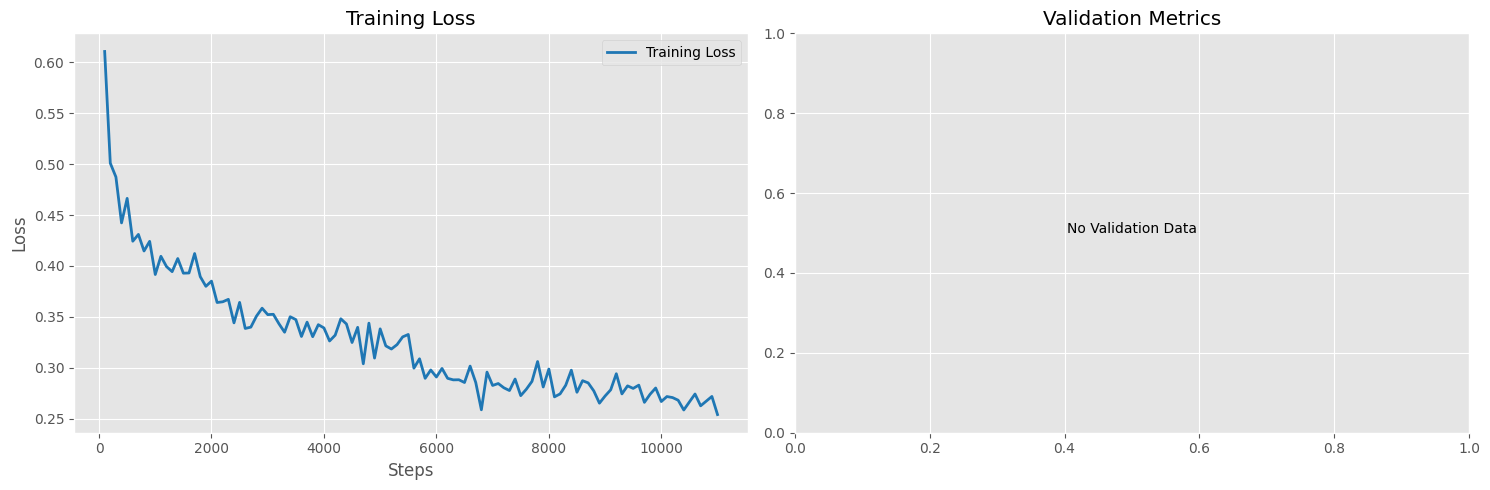

Last recorded loss: 0.2540


In [6]:
# ==========================================
# CELL 11: Generate Graphs from Saved Logs
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import json
from huggingface_hub import hf_hub_download, HfApi

# 1. SETUP: Define your model ID
try:
    api = HfApi()
    username = api.whoami()['name']
except:
    username = "Lifon21" # Fallback based on your screenshot

repo_id = f"{username}/byt5-urdu-headline-generator"
print(f"Fetching file list from: {repo_id}...")

# 2. SEARCH FOR LOGS
# The file might be in a checkpoint folder, not the root.
try:
    files = api.list_repo_files(repo_id=repo_id)
    
    # Priority 1: Look for 'trainer_state.json' anywhere
    json_candidates = [f for f in files if "trainer_state.json" in f]
    
    if json_candidates:
        # Pick the one in the root if it exists, otherwise the last checkpoint
        if "trainer_state.json" in json_candidates:
            target_file = "trainer_state.json"
        else:
            # Sort to find the highest checkpoint number usually
            target_file = sorted(json_candidates)[-1]
            
        print(f"Found log file at: {target_file}")
        log_path = hf_hub_download(repo_id=repo_id, filename=target_file)
        
        with open(log_path, "r") as f:
            data = json.load(f)
            df = pd.DataFrame(data["log_history"])
            
    # Priority 2: Fallback to TensorBoard events if JSON is missing
    elif any("events.out.tfevents" in f for f in files):
        print("⚠️ 'trainer_state.json' not found. Attempting to parse TensorBoard logs...")
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
        
        tb_files = [f for f in files if "events.out.tfevents" in f]
        target_file = tb_files[-1] # Take the last one
        log_path = hf_hub_download(repo_id=repo_id, filename=target_file)
        
        ea = EventAccumulator(log_path)
        ea.Reload()
        
        # Extract scalar data
        steps = []
        loss = []
        for e in ea.Scalars("train/loss"):
            steps.append(e.step)
            loss.append(e.value)
            
        df = pd.DataFrame({"step": steps, "loss": loss})
        # Add eval metrics if they exist
        try:
            eval_loss = [e.value for e in ea.Scalars("eval/loss")]
            eval_steps = [e.step for e in ea.Scalars("eval/loss")]
            # Merge is tricky with mismatched lengths, so we keep it simple for this fallback
        except:
            pass
            
    else:
        print("❌ No log files (JSON or TensorBoard) found in the repo.")
        df = pd.DataFrame()

except Exception as e:
    print(f"❌ Error during search/download: {e}")
    df = pd.DataFrame()

# 3. PLOTTING
if not df.empty:
    plt.style.use('ggplot')
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- PLOT 1: Training Loss ---
    if 'loss' in df.columns and df['loss'].notna().any():
        # Clean data
        train_df = df[df['loss'].notna()]
        axes[0].plot(train_df['step'], train_df['loss'], label='Training Loss', color='tab:blue', linewidth=2)
        axes[0].set_title('Training Loss')
        axes[0].set_xlabel('Steps')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True)
    else:
        axes[0].text(0.5, 0.5, "No Training Data", ha='center')

    # --- PLOT 2: Validation ---
    # Check for evaluation columns
    if 'eval_loss' in df.columns and df['eval_loss'].notna().any():
        eval_df = df[df['eval_loss'].notna()]
        axes[1].plot(eval_df['step'], eval_df['eval_loss'], label='Val Loss', color='tab:red', linestyle='--')
        
        # Check for ROUGE
        if 'eval_rougeL' in df.columns:
            ax2 = axes[1].twinx()
            ax2.plot(eval_df['step'], eval_df['eval_rougeL'], label='ROUGE-L', color='tab:green', linewidth=2)
            ax2.set_ylabel('ROUGE Score')
            
            # Legend handling
            l1, lab1 = axes[1].get_legend_handles_labels()
            l2, lab2 = ax2.get_legend_handles_labels()
            axes[1].legend(l1+l2, lab1+lab2, loc='upper center')
        else:
            axes[1].legend()
            
        axes[1].set_title('Validation Metrics')
        axes[1].set_xlabel('Steps')
    else:
        axes[1].text(0.5, 0.5, "No Validation Data", ha='center')
        axes[1].set_title('Validation Metrics')

    plt.tight_layout()
    plt.show()
    
    # Print Stats
    if 'loss' in df.columns:
        print(f"Last recorded loss: {df['loss'].iloc[-1]:.4f}")
else:
    print("Could not generate plots.")

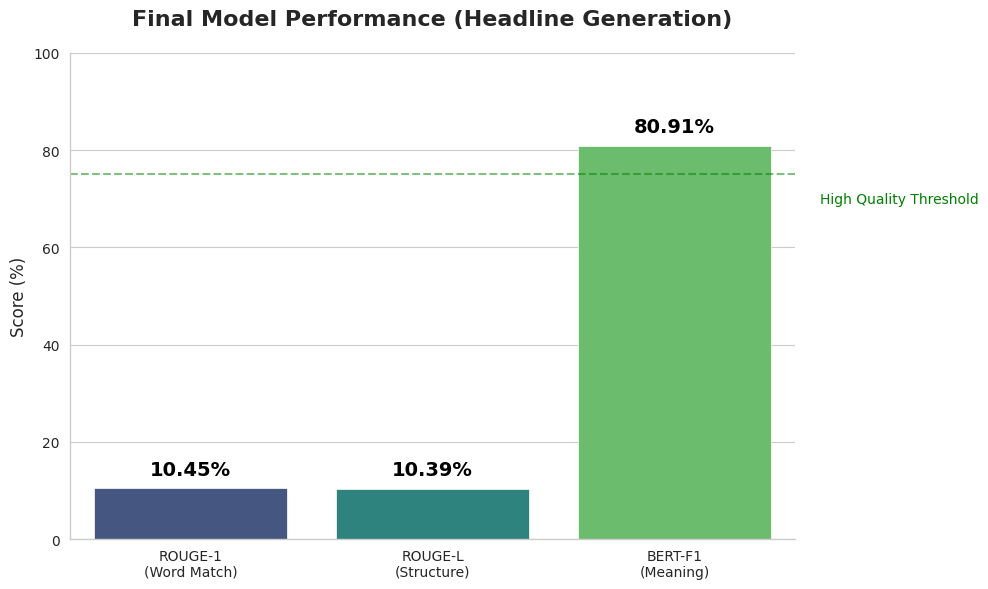

In [10]:
# ==========================================
# CELL 12: Generate Presentation Graph
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# STEP 1: INPUT YOUR FINAL SCORES HERE
# (Copy these numbers from your output in Cell 9 or 10)
# ---------------------------------------------------------
# Example numbers (Replace these with YOUR actual results!)
scores = {
    "ROUGE-1\n(Word Match)": 10.45,   # Replace with your ROUGE-1
    "ROUGE-L\n(Structure)":  10.39,   # Replace with your ROUGE-L
    "BERT-F1\n(Meaning)":    80.91    # Replace with your BERT-F1 (x100)
}
# ---------------------------------------------------------

# Create Dataframe
df = pd.DataFrame(list(scores.items()), columns=['Metric', 'Score'])

# Setup Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create Bar Chart
# Using a professional color palette
bars = sns.barplot(x='Metric', y='Score', data=df, palette="viridis")

# Add Title and Labels
plt.title('Final Model Performance (Headline Generation)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylim(0, 100)  # Scale from 0 to 100

# Add the actual numbers on top of the bars
for i, v in enumerate(df['Score']):
    plt.text(i, v + 2, f"{v}%", ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')

# Add a "Success Zone" line (Optional)
plt.axhline(y=75, color='green', linestyle='--', alpha=0.5)
plt.text(2.6, 70, 'High Quality Threshold', color='green', va='center', fontsize=10)

# Remove top and right borders for a cleaner look
sns.despine()

# Show
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# CELL 13 (SELF-CONTAINED): Calculate BLEU
# ==========================================

# 1. Install necessary libraries (Quiet mode)
print("Installing dependencies...")
!pip install -q evaluate sacrebleu transformers torch datasets pandas tqdm sentencepiece

import torch
from tqdm.auto import tqdm
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from huggingface_hub import HfApi
import evaluate

# --- CONFIGURATION ---
# UPDATE THIS PATH to your actual dataset location on Kaggle
dataset_path = "/kaggle/input/urdu-news-headlinearticle/combined_renumbered.ndjson" 
batch_size = 8
subset_size = None  # Set to 100 if you want a quick test. Set to None for full score.

# 2. AUTO-DETECT MODEL ID
try:
    api = HfApi()
    username = api.whoami()['name']
except:
    username = "Lifon21" # Fallback based on your history
    
model_id = f"{username}/byt5-urdu-headline-generator"
print(f"Target Model: {model_id}")

# 3. LOAD DATA & MODEL
print("Loading dataset and model...")
try:
    # Load and split
    raw_dataset = load_dataset("json", data_files=dataset_path, split="train")
    raw_dataset = raw_dataset.train_test_split(test_size=0.1, seed=42)
    test_dataset = raw_dataset["test"]
    
    if subset_size:
        test_dataset = test_dataset.select(range(subset_size))
        print(f"⚠️ specific subset_size active: Evaluating on first {subset_size} samples only.")
    else:
        print(f"Evaluating on full test set ({len(test_dataset)} samples).")

    # Load Model
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

except Exception as e:
    print(f"❌ Error loading: {e}")
    print("Please check your 'dataset_path' variable.")
    raise e

# 4. GENERATION LOOP (Re-generating predictions)
print("Generating predictions (This takes time)...")
predictions = []
references = []

# Generation settings (High Recall Profile)
gen_kwargs = {
    "max_new_tokens": 256,
    "num_beams": 5,
    # "length_penalty": 1.2,
    # "no_repeat_ngram_size": 3,
    "early_stopping": True
}

for i in tqdm(range(0, len(test_dataset), batch_size), desc="Translating"):
    # Create batch
    batch_indices = range(i, min(i + batch_size, len(test_dataset)))
    batch = test_dataset.select(batch_indices)
    
    # Sanitize inputs (Handle None values)
    clean_texts = [str(t) if t is not None else "" for t in batch["text"]]
    
    # Tokenize
    inputs = tokenizer(
        clean_texts, 
        max_length=1024, 
        truncation=True, 
        padding="max_length", 
        return_tensors="pt"
    ).input_ids.to(device)
    
    # Generate
    with torch.no_grad():
        outputs = model.generate(inputs, **gen_kwargs)
    
    # Decode
    batch_preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    batch_refs = [str(h) if h is not None else "" for h in batch["headline"]]
    
    predictions.extend(batch_preds)
    references.extend(batch_refs)

# 5. CALCULATE BLEU
print("\nComputing BLEU Score...")
bleu = evaluate.load("bleu")

results = bleu.compute(predictions=predictions, references=references)

# 6. DISPLAY RESULTS
print("\n" + "="*30)
print(f"   BLEU SCORE: {results['bleu']*100:.2f}")
print("="*30)
print("\nInterpretation:")
print("- > 30:  Exceptional (Human level)")
print("- 20-30: Very Good for Abstractive Summarization")
print("- 10-20: Average/Acceptable")
print("- < 10:  Poor")

Installing dependencies...
Target Model: Lifon21/byt5-urdu-headline-generator
Loading dataset and model...


Generating train split: 0 examples [00:00, ? examples/s]

Evaluating on full test set (2502 samples).


tokenizer_config.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/797 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Generating predictions (This takes time)...


Translating:   0%|          | 0/313 [00:00<?, ?it/s]